## CODEX GIST — StarDist prediction visualization

Counterpart of `CODEX_hcc/Pred_statistic_visual_hcc_all.ipynb`.

1. Load `Clinical_info` for annotated GIST cores (550).
2. Plot **pooled StarDist ROC** for L2 / L12 / L1.
3. Screen GIST TMA clinical fields (`tma_position`, `site`, `size`, `mitotic_rate`, `mutation_status`, `risk`, `primary`), recode to ≤3 groups, then compare per-core **macro AUROC** vs **coverslip** (3 colors) and those recoded groups.

Shared helpers: `Hist2Pheno_pkg/uni_label_cv_helpers.py`. Clinical loaders: `CODEX_pdac/s1167_plot.py`.


In [1]:
## Setup (CODEX GIST)
import matplotlib
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

import sys
import warnings
import logging
from pathlib import Path

warnings.filterwarnings("ignore")
logging.getLogger("ome_zarr").setLevel(logging.ERROR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPO = Path("/home/lingyu/ssd2/Python/Hist2Pheno")
CODE_DIR = REPO / "code"
PKG_DIR = CODE_DIR / "Hist2Pheno_pkg"
PDAC_CODE_DIR = CODE_DIR / "CODEX_pdac"

for _p in (PKG_DIR, PDAC_CODE_DIR):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

PAN_ORGAN = "codex_gist"
DATA_ROOT = REPO / "data" / "CODEX" / "HCC" / "Michael_data_transfer" / "s1167"
STARDIST_RESULT_ROOT = DATA_ROOT / "result_all_spatial_gist" / "stardist"
OUT_DIR = DATA_ROOT / "result_all_spatial_gist" / "clinical_viz_gist"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("OUT_DIR  :", OUT_DIR)
print("pan_organ:", PAN_ORGAN)


DATA_ROOT: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167
OUT_DIR  : /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_gist/clinical_viz_gist
pan_organ: codex_gist


## Load clinical information

`raw_metadata_updated.xlsx` sheet `Clinical_info`, `cohort='GIST TMA'`, annotated cores only.
Demo ACQ: `Charvill-94_c013_v001_r001_reg002`.


In [2]:
import importlib
import s1167_plot
importlib.reload(s1167_plot)
from s1167_plot import load_s1167_clinical_info

clinical = load_s1167_clinical_info(cohort="GIST TMA", annotated_only=True)
print(f"Clinical cores: {len(clinical)}")
print("Datasets (first 6):")
for i, acq in enumerate(clinical["ACQUISITION_ID"].astype(str).head(6), start=1):
    print(f"  {i}. {acq}")


Clinical rows: 550 (cohort=GIST TMA)


,ACQUISITION_ID,coverslip,SAMPLE_LABEL,SAMPLE_ID,tissue_type
0,Charvill-94_c011_v001_r001_reg002,c011,TA-429A_2,31016.0,GIST TMA
1,Charvill-94_c011_v001_r001_reg003,c011,TA-429A_3,31017.0,GIST TMA
2,Charvill-94_c011_v001_r001_reg004,c011,TA-429A_4,31018.0,GIST TMA
3,Charvill-94_c011_v001_r001_reg007,c011,TA-429A_7,31025.0,GIST TMA
4,Charvill-94_c011_v001_r001_reg010,c011,TA-429A_10,31030.0,GIST TMA
5,Charvill-94_c011_v001_r001_reg011,c011,TA-429A_11,31031.0,GIST TMA
6,Charvill-94_c011_v001_r001_reg012,c011,TA-429A_14,31022.0,GIST TMA
7,Charvill-94_c011_v001_r001_reg014,c011,TA-429A_16,30993.0,GIST TMA
8,Charvill-94_c011_v001_r001_reg016,c011,TA-429A_18,30979.0,GIST TMA
9,Charvill-94_c011_v001_r001_reg026,c011,TA-429A_28,30957.0,GIST TMA



coverslip


coverslip
c011    197
c013    193
c009    160
Name: count, dtype: int64


SAMPLE_LABEL


SAMPLE_LABEL
TA-429B       193
TA-339_139      1
TA-339_133      1
TA-339_125      1
TA-339_28       1
             ... 
TA-339_12       1
TA-339_11       1
TA-339_9        1
TA-339_8        1
TA-339_27       1
Name: count, Length: 358, dtype: int64

Clinical cores: 550
Datasets (first 6):
  1. Charvill-94_c011_v001_r001_reg002
  2. Charvill-94_c011_v001_r001_reg003
  3. Charvill-94_c011_v001_r001_reg004
  4. Charvill-94_c011_v001_r001_reg007
  5. Charvill-94_c011_v001_r001_reg010
  6. Charvill-94_c011_v001_r001_reg011


## Pooled StarDist ROC (annotated GIST cores)

Symlink the cores present in `clinical`, then plot pooled OvR ROC for `l2` / `l12` / `l1`.


Linked 550/550 StarDist sample dirs under /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_gist/clinical_viz_gist/_tmp_selected_stardist
Pooled StarDist ROC over 550 linked cores

=== L2 | discovering validation_external_stardist_matched_AUROC.csv ===
  Charvill-94_c009_v001_r001_reg001: 5,257 cells, 11 local classes
  Charvill-94_c009_v001_r001_reg002: 2,618 cells, 11 local classes
  Charvill-94_c009_v001_r001_reg003: 8,727 cells, 11 local classes
  Charvill-94_c009_v001_r001_reg004: 12,090 cells, 11 local classes
  Charvill-94_c009_v001_r001_reg005: 4,110 cells, 11 local classes
  Charvill-94_c009_v001_r001_reg006: 3,011 cells, 11 local classes
  Charvill-94_c009_v001_r001_reg007: 10,591 cells, 11 local classes
  Charvill-94_c009_v001_r001_reg008: 6,977 cells, 11 local classes
  Charvill-94_c009_v001_r001_reg009: 3,627 cells, 11 local classes
  Charvill-94_c009_v001_r001_reg010: 144 cells, 11 local classes
  Charvill-94_c009_v001_r001_

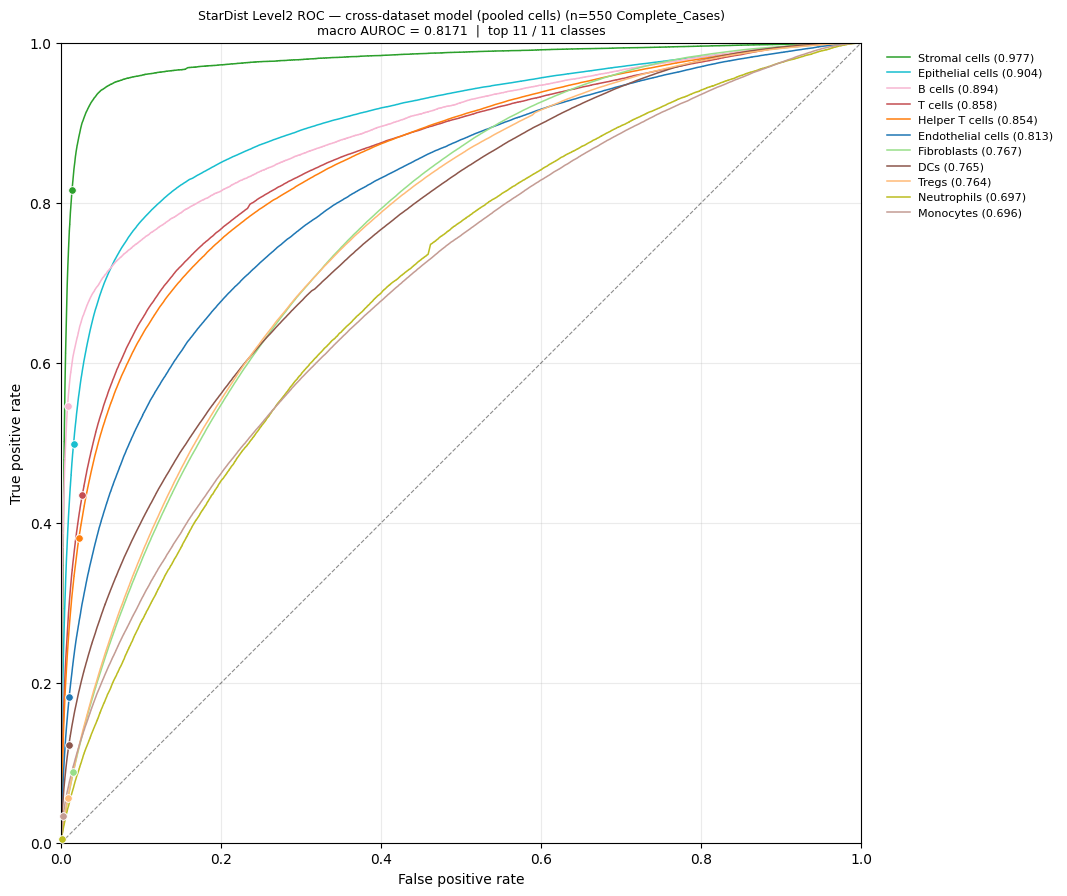

Pooled macro AUROC (L2): 0.8171

=== L12 | discovering validation_external_stardist_matched_AUROC_level12.csv ===
  Charvill-94_c009_v001_r001_reg001: 5,257 cells, 6 local classes
  Charvill-94_c009_v001_r001_reg002: 2,618 cells, 6 local classes
  Charvill-94_c009_v001_r001_reg003: 8,727 cells, 6 local classes
  Charvill-94_c009_v001_r001_reg004: 12,090 cells, 6 local classes
  Charvill-94_c009_v001_r001_reg005: 4,110 cells, 6 local classes
  Charvill-94_c009_v001_r001_reg006: 3,011 cells, 6 local classes
  Charvill-94_c009_v001_r001_reg007: 10,591 cells, 6 local classes
  Charvill-94_c009_v001_r001_reg008: 6,977 cells, 6 local classes
  Charvill-94_c009_v001_r001_reg009: 3,627 cells, 6 local classes
  Charvill-94_c009_v001_r001_reg010: 144 cells, 6 local classes
  Charvill-94_c009_v001_r001_reg011: 5,823 cells, 6 local classes
  Charvill-94_c009_v001_r001_reg012: 6,867 cells, 6 local classes
  Charvill-94_c009_v001_r001_reg013: 1,502 cells, 6 local classes
  Charvill-94_c009_v001_r001

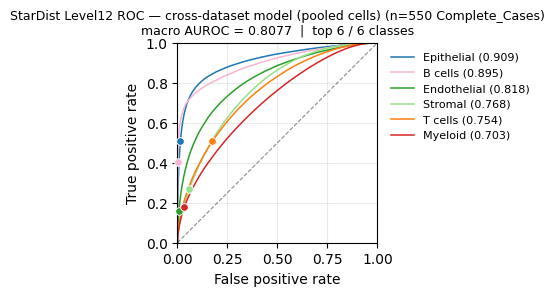

Pooled macro AUROC (L12): 0.8077

=== L1 | discovering validation_external_stardist_matched_AUROC_level1.csv ===
  Charvill-94_c009_v001_r001_reg001: 5,257 cells, 4 local classes
  Charvill-94_c009_v001_r001_reg002: 2,618 cells, 4 local classes
  Charvill-94_c009_v001_r001_reg003: 8,727 cells, 4 local classes
  Charvill-94_c009_v001_r001_reg004: 12,090 cells, 4 local classes
  Charvill-94_c009_v001_r001_reg005: 4,110 cells, 4 local classes
  Charvill-94_c009_v001_r001_reg006: 3,011 cells, 4 local classes
  Charvill-94_c009_v001_r001_reg007: 10,591 cells, 4 local classes
  Charvill-94_c009_v001_r001_reg008: 6,977 cells, 4 local classes
  Charvill-94_c009_v001_r001_reg009: 3,627 cells, 4 local classes
  Charvill-94_c009_v001_r001_reg010: 144 cells, 4 local classes
  Charvill-94_c009_v001_r001_reg011: 5,823 cells, 4 local classes
  Charvill-94_c009_v001_r001_reg012: 6,867 cells, 4 local classes
  Charvill-94_c009_v001_r001_reg013: 1,502 cells, 4 local classes
  Charvill-94_c009_v001_r001_

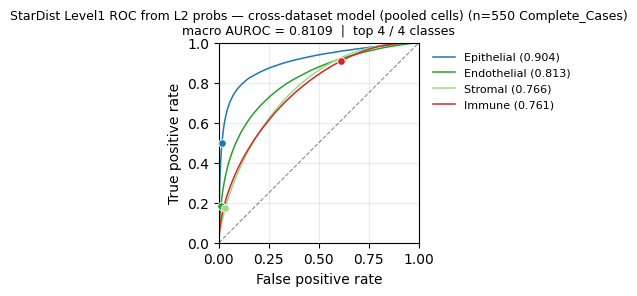

Pooled macro AUROC (L1): 0.8109


In [3]:
import importlib
import uni_label_cv_helpers as uni_nb
import s1167_plot

importlib.reload(uni_nb)
importlib.reload(s1167_plot)
from s1167_plot import PDAC_STARDIST_MACRO_AUROC_TIERS
from uni_label_cv_helpers import plot_pooled_stardist_tier_rocs, symlink_stardist_sample_dirs

filtered_root = symlink_stardist_sample_dirs(
    STARDIST_RESULT_ROOT,
    clinical["ACQUISITION_ID"],
    OUT_DIR / "_tmp_selected_stardist",
)
print(f"Pooled StarDist ROC over {len(list(Path(filtered_root).iterdir()))} linked cores")

pooled_roc = plot_pooled_stardist_tier_rocs(
    filtered_root,
    OUT_DIR,
    PDAC_STARDIST_MACRO_AUROC_TIERS,
    layout="pooled_stardist",
    pan_organ=PAN_ORGAN,
    figsize={"l12": (2.0, 2.0), "l1": (2.0, 2.0)},
)


## <span style="color:red;">StarDist macro AUROC vs clinical groups</span>

GIST TMA rows in `Clinical_info` (`tissue_type == GIST TMA`). Many cores lack the extra fields (only ~197 / 550 have any of them).

1. **Screen** raw columns: `tma_position`, `site`, `size`, `mitotic_rate`, `mutation_status`, `risk`, `primary`.
2. **Recode** each to ≤3 analysis groups (drop `Missing` / `Unknown` / `Control` from AUROC tests).
3. **Coverslip** (first panel): all 550 cores, **3 groups** (`c009` / `c011` / `c013`), scatter colored by group (not by sample — no 500-item legend).
4. Then one AUROC figure per recoded clinical variable.

- `method="rank"`: Mann–Whitney U (2 groups) or Kruskal–Wallis (3+)
- `method="parametric"`: Welch t-test / one-way ANOVA


In [6]:
import importlib
import sys
import uni_label_cv_helpers as uni_nb
import s1167_plot

_xenium_lung = str(CODE_DIR / "Xenium_lung")
if _xenium_lung not in sys.path:
    sys.path.insert(0, _xenium_lung)
import histology_derived_niche_index as niche_nb
import plotting_palettes as pal_nb

importlib.reload(pal_nb)
importlib.reload(niche_nb)
importlib.reload(uni_nb)
importlib.reload(s1167_plot)
from s1167_plot import (
    GIST_TMA_CLINICAL_GROUP_COLUMNS,
    GIST_TMA_CLINICAL_RAW_COLUMNS,
    analyze_gist_stardist_macro_auroc_by_clinical,
    recode_gist_tma_clinical,
    summarize_gist_tma_clinical,
)

clinical_gist = recode_gist_tma_clinical(clinical)
clin_summary = summarize_gist_tma_clinical(clinical_gist)
print("GIST TMA clinical screening (raw fields)")
display(clin_summary)

print("\nRaw value counts (including NA)")
for col in GIST_TMA_CLINICAL_RAW_COLUMNS:
    if col not in clinical_gist.columns:
        print(f"  missing column: {col}")
        continue
    print(f"\n=== {col} ===")
    display(clinical_gist[col].value_counts(dropna=False).head(15).to_frame("n"))

print("\nRecoded groups (≤3 levels + Missing/Unknown/Control)")
for col in GIST_TMA_CLINICAL_GROUP_COLUMNS:
    if col not in clinical_gist.columns:
        continue
    print(f"\n=== {col} ===")
    display(clinical_gist[col].value_counts(dropna=False).to_frame("n"))


GIST TMA clinical screening (raw fields)


,column,n,n_missing,n_nonmissing,n_unique,present
0,tma_position,550,353,197,197,True
1,site,550,353,197,42,True
2,size,550,426,124,54,True
3,mitotic_rate,550,458,92,25,True
4,mutation_status,550,377,173,17,True
5,risk,550,377,173,9,True
6,primary,550,379,171,7,True



Raw value counts (including NA)

=== tma_position ===


,n
tma_position,
NaN,353
2_4_9,1
2_4_7,1
2_4_5,1
2_3_10,1
2_3_9,1
2_3_8,1
2_3_7,1
2_3_6,1



=== site ===


...

,n
risk_group,
Missing,377
High,95
Unknown,32
Low,20
Control,18
Intermediate,8



=== primary_group ===


,n
primary_group,
Missing,379
Primary,141
Metastasis,26
Unknown,4



=== tma_block ===


,n
tma_block,
Missing,353
4,101
2,96


### Coverslip (keep the original first panel)

All 550 cores. Three groups, three colors. Scatter legend is **coverslip**, not individual ACQUISITION_IDs.

Overall Kruskal–Wallis plus **pairwise Mann–Whitney U** (Holm-adjusted) between every two coverslips.


=== L2 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,coverslip,macro_auc_l2,rank,Kruskal-Wallis,0.000004,24.909696,3,"[c009, c011, c013]","[0.6637334441951486, 0.6376106924892722, 0.628...","[0.6637334441951486, 0.6376106924892722, 0.628...",5.409072


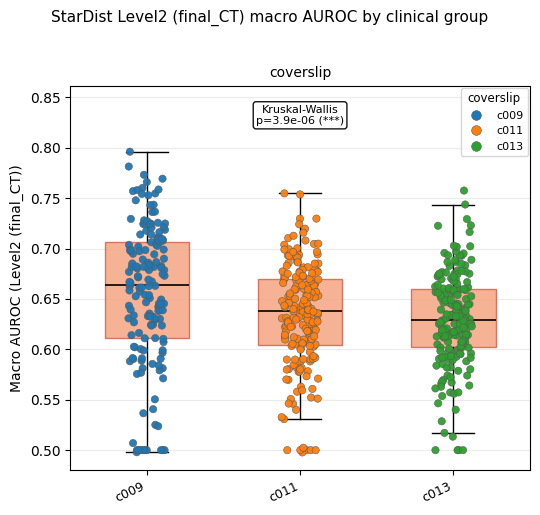


=== L12 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,coverslip,macro_auc_l12,rank,Kruskal-Wallis,1.197317e-08,36.481195,3,"[c009, c011, c013]","[0.682747266704687, 0.6322510073875198, 0.6336...","[0.682747266704687, 0.6322510073875198, 0.6336...",7.921791


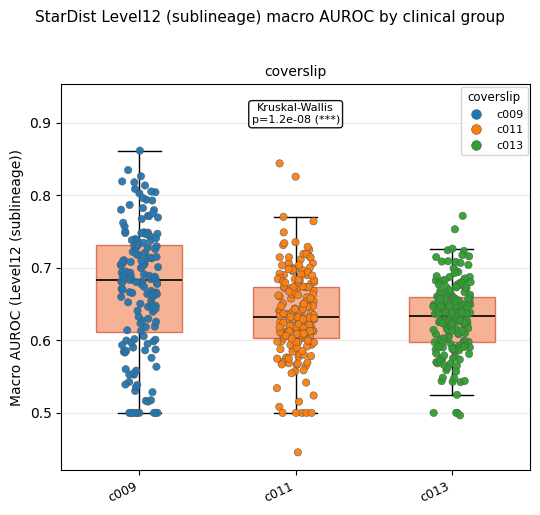


=== L1 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,coverslip,macro_auc_l1,rank,Kruskal-Wallis,0.000009,23.177832,3,"[c009, c011, c013]","[0.6916795044952784, 0.6533200599466705, 0.655...","[0.6916795044952784, 0.6533200599466705, 0.655...",5.033002


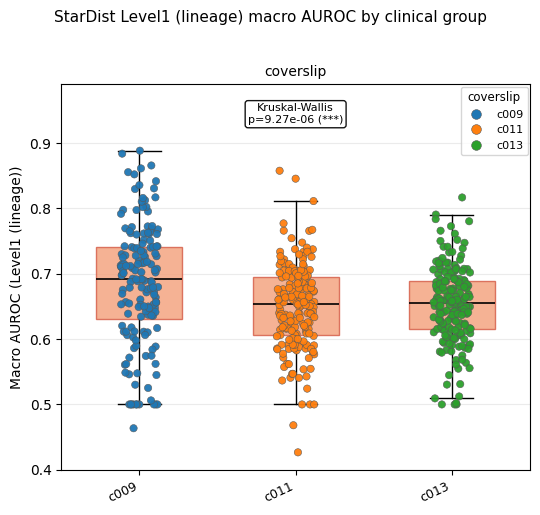

In [7]:
import importlib
import sys
import uni_label_cv_helpers as uni_nb
import s1167_plot

_xenium_lung = str(CODE_DIR / "Xenium_lung")
if _xenium_lung not in sys.path:
    sys.path.insert(0, _xenium_lung)
import histology_derived_niche_index as niche_nb
import plotting_palettes as pal_nb

importlib.reload(pal_nb)
importlib.reload(niche_nb)
importlib.reload(uni_nb)
importlib.reload(s1167_plot)
from s1167_plot import analyze_gist_stardist_macro_auroc_by_clinical

stardist_auroc_coverslip = analyze_gist_stardist_macro_auroc_by_clinical(
    filtered_root,
    clinical_gist,
    method="rank",
    pan_organ=PAN_ORGAN,
    clinical_columns=("coverslip",),
    color_by="group",
    pairwise=True,
    pairwise_correction="holm",
    figsize=(5.5, 5.0),
    save_dir=OUT_DIR,
)

### Recoded GIST clinical variables

Each plot uses cores with a non-missing recoded label (`Missing` / `Unknown` / `Control` dropped). Scatter is still colored by the **3 (or 2) groups**, not by sample.

Same pairwise tests as coverslip: every two groups get a Mann–Whitney U (Holm-adjusted); 3+ groups also keep Kruskal–Wallis.


site_group: 197 cores, 3 groups

=== L2 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,site_group,macro_auc_l2,rank,Kruskal-Wallis,0.32431,3.472774,4,"[Stomach, Small intestine, Other, nan]","[0.6331829972866285, 0.642591854581254, 0.6360...","[0.6331829972866285, 0.642591854581254, 0.6360...",0.489039


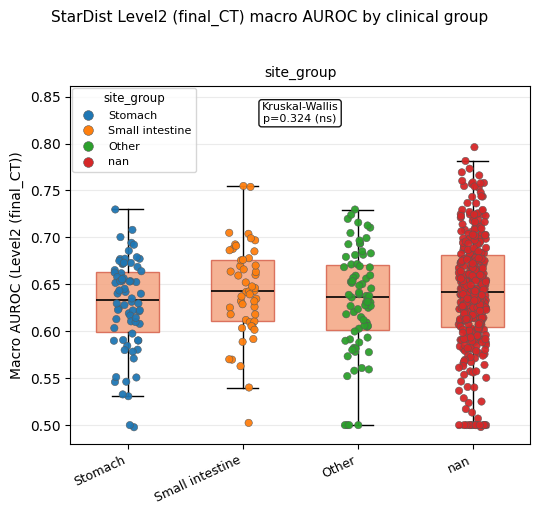


=== L12 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,site_group,macro_auc_l12,rank,Kruskal-Wallis,0.08228,6.695034,4,"[Stomach, Small intestine, Other, nan]","[0.6295375124896898, 0.6410384869190695, 0.632...","[0.6295375124896898, 0.6410384869190695, 0.632...",1.084705


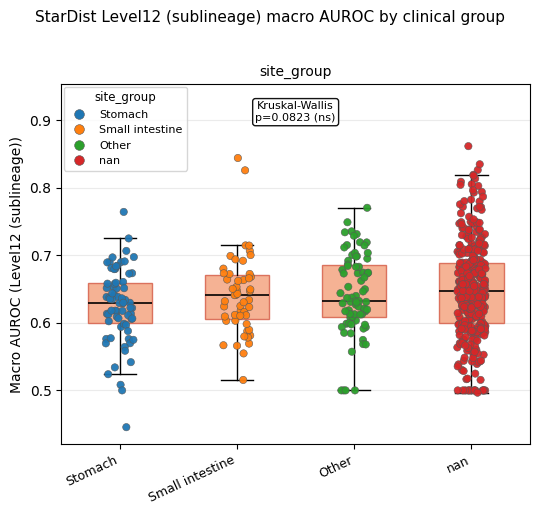


=== L1 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,site_group,macro_auc_l1,rank,Kruskal-Wallis,0.017226,10.16358,4,"[Stomach, Small intestine, Other, nan]","[0.6392614319404581, 0.6589454753381645, 0.660...","[0.6392614319404581, 0.6589454753381645, 0.660...",1.763825


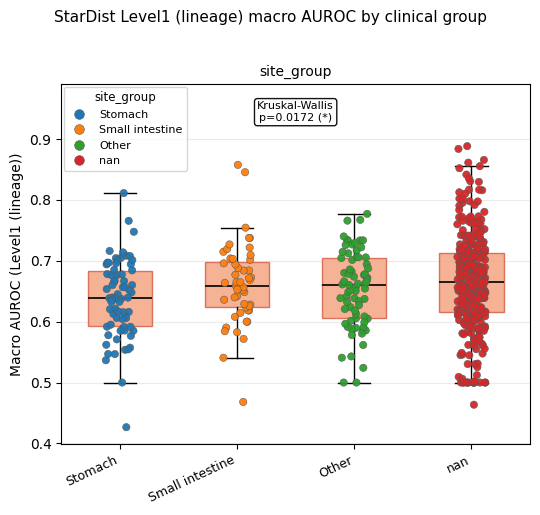


size_group: 124 cores, 3 groups

=== L2 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,size_group,macro_auc_l2,rank,Kruskal-Wallis,0.084515,6.634264,4,"[<5 cm, 5–10 cm, ≥10 cm, nan]","[0.6360602640661355, 0.6496818841152261, 0.615...","[0.6360602640661355, 0.6496818841152261, 0.615...",1.073065


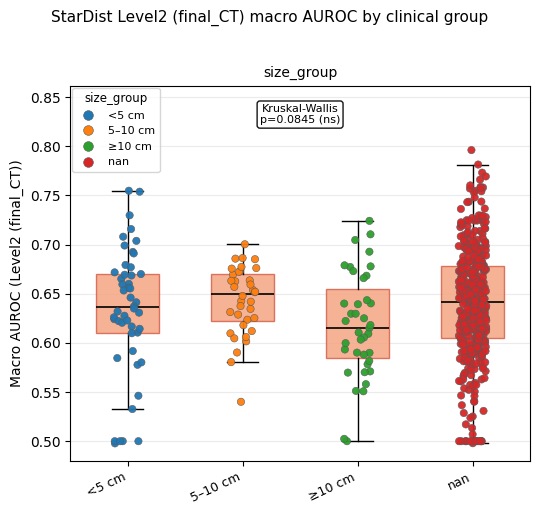


=== L12 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,size_group,macro_auc_l12,rank,Kruskal-Wallis,0.009849,11.377877,4,"[<5 cm, 5–10 cm, ≥10 cm, nan]","[0.6300484509499008, 0.6384360487167069, 0.611...","[0.6300484509499008, 0.6384360487167069, 0.611...",2.006626


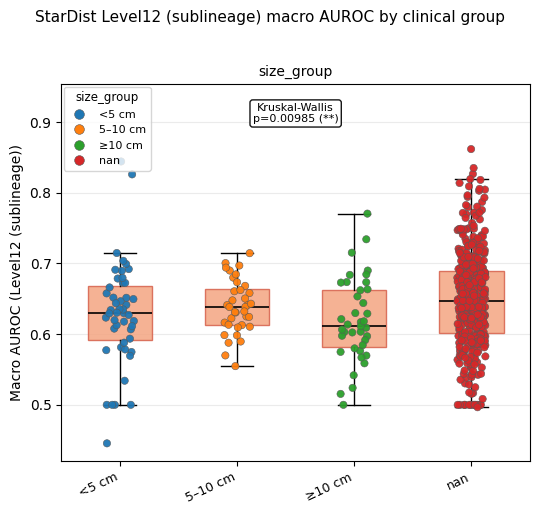


=== L1 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,size_group,macro_auc_l1,rank,Kruskal-Wallis,0.00188,14.927197,4,"[<5 cm, 5–10 cm, ≥10 cm, nan]","[0.6391576519079729, 0.6620204846353797, 0.620...","[0.6391576519079729, 0.6620204846353797, 0.620...",2.725858


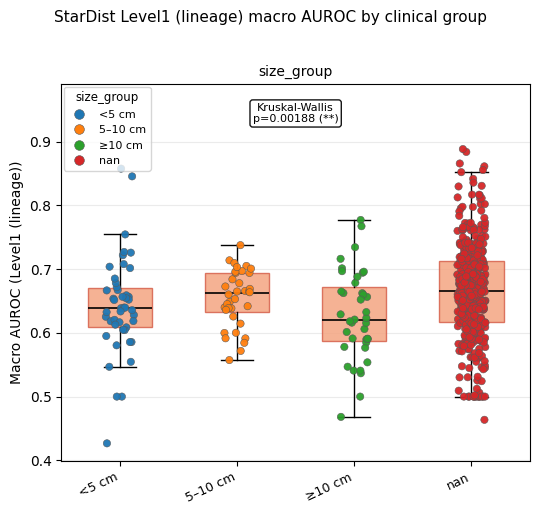


mitotic_group: 92 cores, 2 groups

=== L2 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,mitotic_group,macro_auc_l2,rank,Kruskal-Wallis,0.402564,1.819803,3,"[≤5 /50 HPF, >5 /50 HPF, nan]","[0.6393576294088047, 0.6292512354981066, 0.641...","[0.6393576294088047, 0.6292512354981066, 0.641...",0.395165


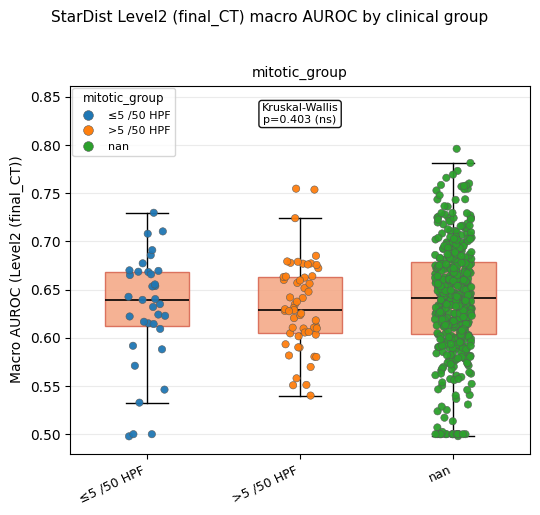


=== L12 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,mitotic_group,macro_auc_l12,rank,Kruskal-Wallis,0.067358,5.395469,3,"[≤5 /50 HPF, >5 /50 HPF, nan]","[0.6410384869190695, 0.6260404217786986, 0.645...","[0.6410384869190695, 0.6260404217786986, 0.645...",1.171611


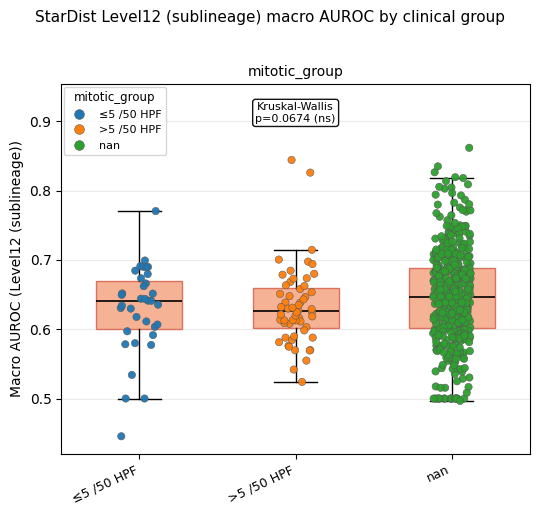


=== L1 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,mitotic_group,macro_auc_l1,rank,Kruskal-Wallis,0.003881,11.103376,3,"[≤5 /50 HPF, >5 /50 HPF, nan]","[0.6356867461019987, 0.6408118158798171, 0.664...","[0.6356867461019987, 0.6408118158798171, 0.664...",2.411067


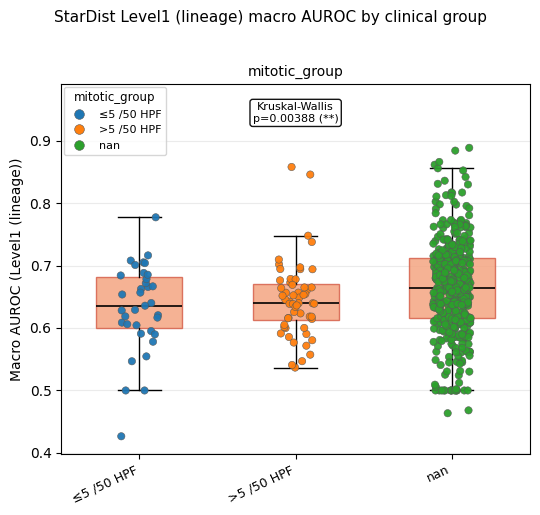


mutation_group: 161 cores, 2 groups

=== L2 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,mutation_group,macro_auc_l2,rank,Kruskal-Wallis,0.477588,1.478013,3,"[KIT, Non-KIT, nan]","[0.6345855936090425, 0.6412977283543746, 0.642...","[0.6345855936090425, 0.6412977283543746, 0.642...",0.320946


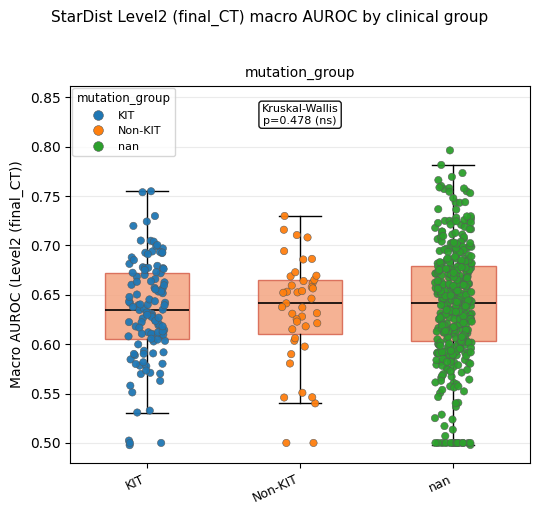


=== L12 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,mutation_group,macro_auc_l12,rank,Kruskal-Wallis,0.022955,7.54847,3,"[KIT, Non-KIT, nan]","[0.6291987141034595, 0.6363478364001308, 0.647...","[0.6291987141034595, 0.6363478364001308, 0.647...",1.639129


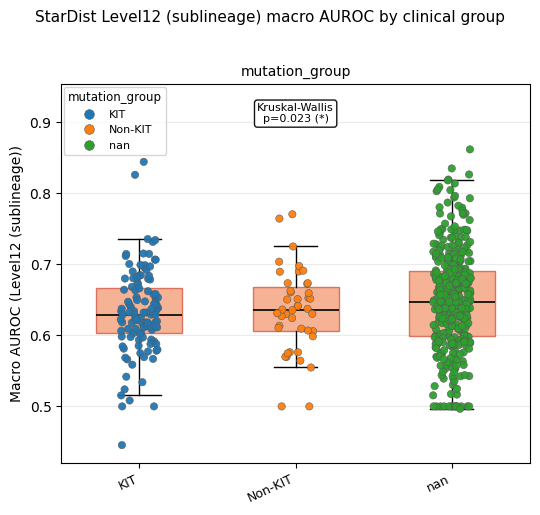


=== L1 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,mutation_group,macro_auc_l1,rank,Kruskal-Wallis,0.001227,13.40654,3,"[KIT, Non-KIT, nan]","[0.6396457669246292, 0.6578011661996788, 0.667...","[0.6396457669246292, 0.6578011661996788, 0.667...",2.911193


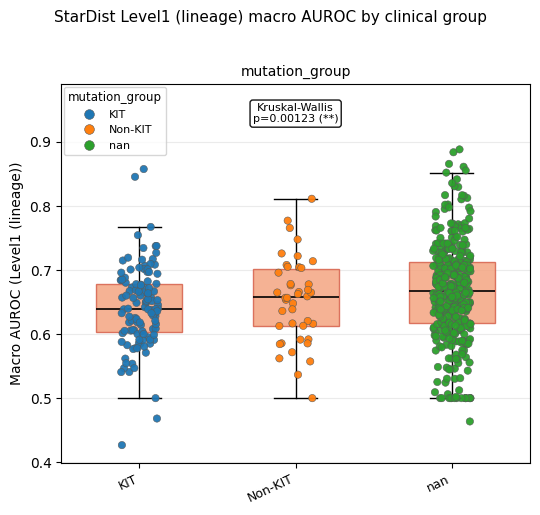


risk_group: 123 cores, 3 groups

=== L2 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,risk_group,macro_auc_l2,rank,Kruskal-Wallis,0.445813,2.6673,4,"[Low, Intermediate, High, nan]","[0.6280640773101844, 0.6600941923876825, 0.637...","[0.6280640773101844, 0.6600941923876825, 0.637...",0.350847


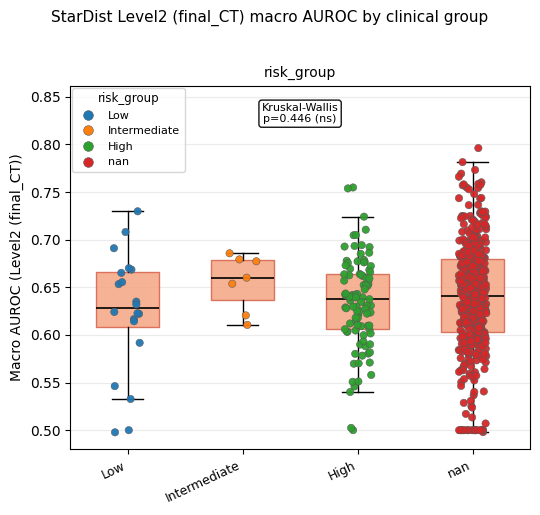


=== L12 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,risk_group,macro_auc_l12,rank,Kruskal-Wallis,0.14379,5.415347,4,"[Low, Intermediate, High, nan]","[0.6347602970411161, 0.6412209333797547, 0.629...","[0.6347602970411161, 0.6412209333797547, 0.629...",0.84227


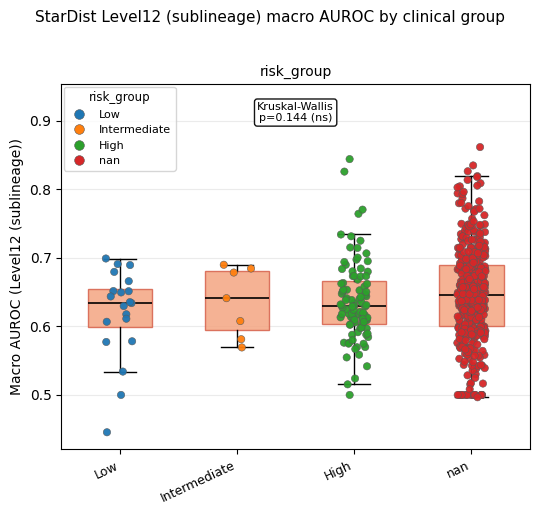


=== L1 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,risk_group,macro_auc_l1,rank,Kruskal-Wallis,0.00846,11.706194,4,"[Low, Intermediate, High, nan]","[0.6242758938637585, 0.6657383590353614, 0.648...","[0.6242758938637585, 0.6657383590353614, 0.648...",2.072605


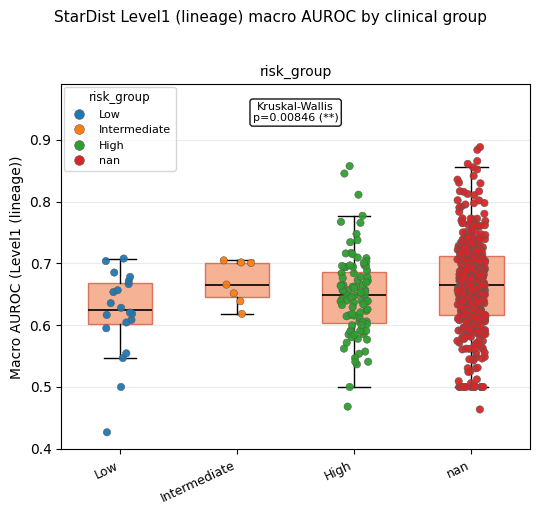


primary_group: 167 cores, 2 groups

=== L2 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,primary_group,macro_auc_l2,rank,Kruskal-Wallis,0.352644,2.084594,3,"[Primary, Metastasis, nan]","[0.6360602640661355, 0.6385635493399331, 0.642...","[0.6360602640661355, 0.6385635493399331, 0.642...",0.452664


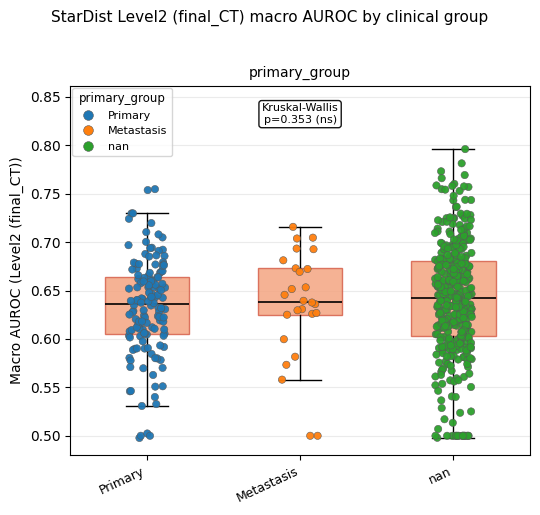


=== L12 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,primary_group,macro_auc_l12,rank,Kruskal-Wallis,0.00693,9.943909,3,"[Primary, Metastasis, nan]","[0.6295375124896898, 0.6372486822600896, 0.648...","[0.6295375124896898, 0.6372486822600896, 0.648...",2.159292


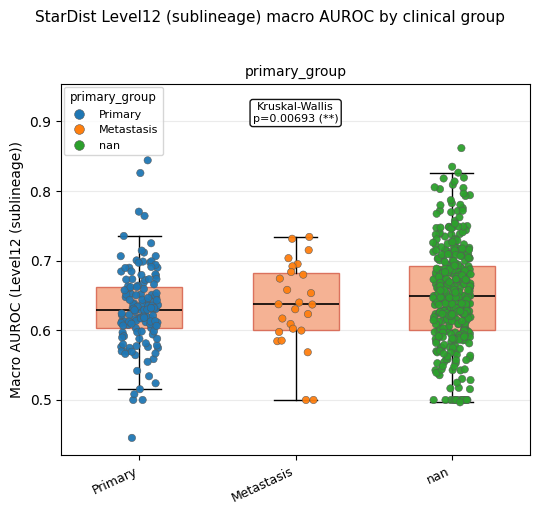


=== L1 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,primary_group,macro_auc_l1,rank,Kruskal-Wallis,0.001483,13.026924,3,"[Primary, Metastasis, nan]","[0.6486577464627284, 0.6488226330323672, 0.668...","[0.6486577464627284, 0.6488226330323672, 0.668...",2.82876


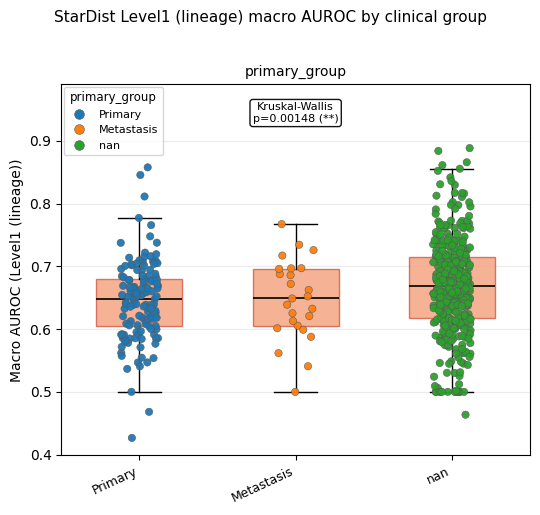


tma_block: 197 cores, 2 groups

=== L2 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,tma_block,macro_auc_l2,rank,Kruskal-Wallis,0.428552,1.694685,3,"[2, 4, nan]","[0.637540339547071, 0.6376810454314733, 0.6421...","[0.637540339547071, 0.6376810454314733, 0.6421...",0.367996


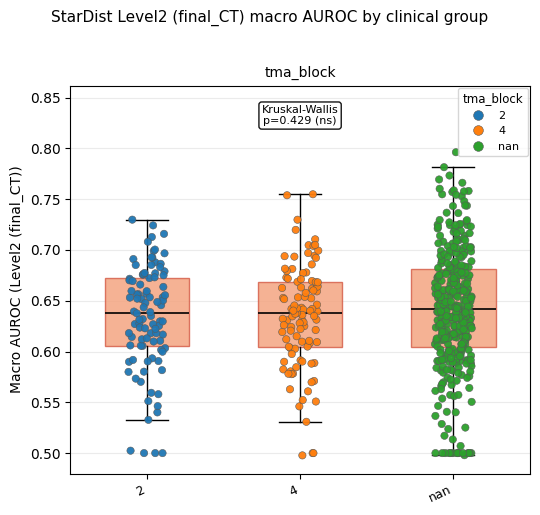


=== L12 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,tma_block,macro_auc_l12,rank,Kruskal-Wallis,0.106217,4.484534,3,"[2, 4, nan]","[0.6311129430558309, 0.63404341865837, 0.64724...","[0.6311129430558309, 0.63404341865837, 0.64724...",0.973804


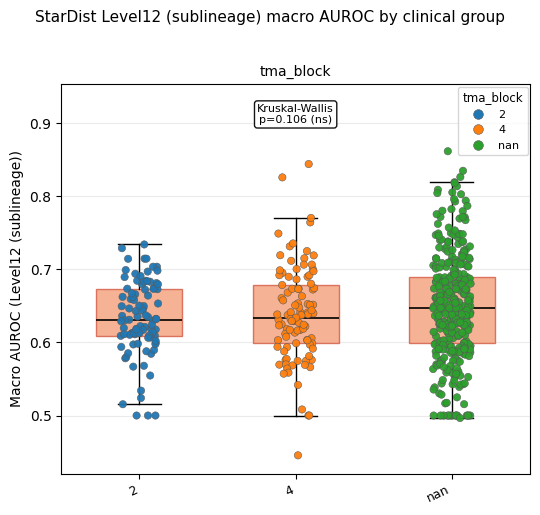


=== L1 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,tma_block,macro_auc_l1,rank,Kruskal-Wallis,0.032663,6.843037,3,"[2, 4, nan]","[0.6526091291983064, 0.6550566623060317, 0.664...","[0.6526091291983064, 0.6550566623060317, 0.664...",1.485947


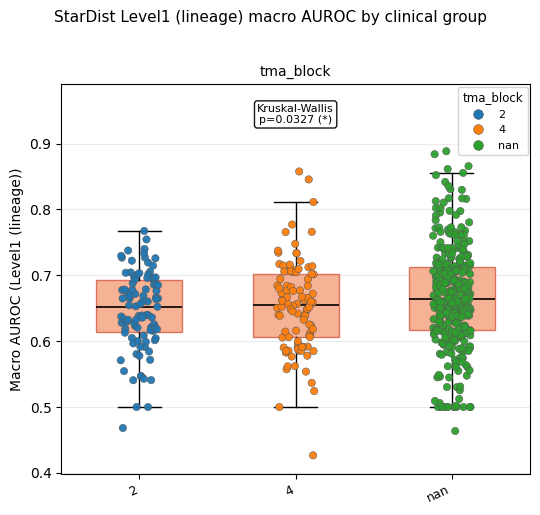

In [8]:
DROP_LEVELS = {"Missing", "Unknown", "Control", "nan", "None"}
stardist_auroc_clinical = {}
for col in GIST_TMA_CLINICAL_GROUP_COLUMNS:
    if col not in clinical_gist.columns:
        continue
    sub = clinical_gist.loc[~clinical_gist[col].astype(str).isin(DROP_LEVELS)].copy()
    n_lv = sub[col].nunique(dropna=True)
    print(f"\n{'=' * 60}\n{col}: {len(sub)} cores, {n_lv} groups")
    if n_lv < 2 or len(sub) < 8:
        print("  skip (need ≥2 groups and enough cores)")
        continue
    stardist_auroc_clinical[col] = analyze_gist_stardist_macro_auroc_by_clinical(
        filtered_root,
        sub,
        method="rank",
        pan_organ=PAN_ORGAN,
        clinical_columns=(col,),
        color_by="group",
        pairwise=True,
        pairwise_correction="holm",
        figsize=(5.5, 5.0),
        save_dir=OUT_DIR,
    )